# Task 2.1: Dataset Selection and Setup
## Paper: Training and Testing Low-degree Polynomial Data Mappings via Linear SVM
**Authors:** Yin-Wen Chang, Cho-Jui Hsieh, Kai-Wei Chang, Michael Ringgaard, Chih-Jen Lin (2010)

---

## Dataset Selection

**Dataset:** 20 Newsgroups (full corpus, binary grouping) — all 20 categories split into two macro-groups: *comp/sci/talk* topics (class +1) vs *alt/misc/rec/soc* topics (class −1), represented as TF-IDF sparse features via `TfidfVectorizer(max_features=3000)`.

**Why appropriate for this paper:** The paper's core claim is that explicit polynomial mapping + linear SVM is faster than kernel SVM on **large, sparse** datasets. Our dataset provides ~15,000 training instances with sparse TF-IDF features ($\bar{n} \ll n$), directly matching the sparsity assumption from Section 3.3. The paper benchmarks on text classification datasets of similar character (rcv1, news20 in Table 3), so the domain aligns well. Using all 20 categories instead of just 2 gives us enough instances ($l \approx 15{,}000$) to meaningfully demonstrate the training speedup, since the paper's advantage requires $\bar{n}/2 \ll l$ (Equation 10).

**Limitations compared to paper's datasets:** The paper's largest dataset (rcv1) has 677,399 instances with 47,236 features — an order of magnitude larger than ours. Their reported speedups of 4× to 4,600× reflect that scale; our smaller dataset will show a more modest speedup. We also use scikit-learn's LinearSVC and SVC rather than the paper's optimized LIBLINEAR/LIBSVM implementations.

**Preprocessing steps:**
1. Load all 20 newsgroups categories (headers/footers/quotes removed for clean text).
2. Group categories into two binary classes: comp/sci/talk → +1, others → −1.
3. Apply TF-IDF vectorization with `max_features=3000`.
4. Train/test split (80/20, stratified).
5. Verify sparsity statistics to confirm the dataset satisfies the paper's assumptions.

In [1]:
import numpy as np
import scipy.sparse as sp
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Load all 20 newsgroups
newsgroups = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

# Binary grouping: comp/sci/talk categories → +1, rest → −1
group1_keywords = ['comp', 'sci', 'talk']
cat_to_label = {}
for i, name in enumerate(newsgroups.target_names):
    cat_to_label[i] = 1 if any(k in name for k in group1_keywords) else -1

y = np.array([cat_to_label[t] for t in newsgroups.target])

print("Category grouping:")
for i, name in enumerate(newsgroups.target_names):
    print(f"  {name}: {'+1' if cat_to_label[i] == 1 else '-1'}")

# TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X = vectorizer.fit_transform(newsgroups.data)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDataset: 20 Newsgroups (binary grouping)")
print(f"Total samples: {X.shape[0]}")
print(f"Training samples (l): {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features (n): {X.shape[1]}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

Category grouping:
  alt.atheism: -1
  comp.graphics: +1
  comp.os.ms-windows.misc: +1
  comp.sys.ibm.pc.hardware: +1
  comp.sys.mac.hardware: +1
  comp.windows.x: +1
  misc.forsale: -1
  rec.autos: -1
  rec.motorcycles: -1
  rec.sport.baseball: -1
  rec.sport.hockey: -1
  sci.crypt: +1
  sci.electronics: +1
  sci.med: +1
  sci.space: +1
  soc.religion.christian: -1
  talk.politics.guns: +1
  talk.politics.mideast: +1
  talk.politics.misc: +1
  talk.religion.misc: +1

Dataset: 20 Newsgroups (binary grouping)
Total samples: 18846
Training samples (l): 15076
Test samples: 3770
Features (n): 3000
Class distribution: {-1: 6750, 1: 12096}


### Explanation
We load all 20 newsgroups and group them into a binary classification problem. TF-IDF features create a sparse representation matching the paper's setup — labels are $\{-1, +1\}$ as per Equation (1).

In [2]:
# Sparsity statistics — key for understanding method applicability
nnz_per_row = np.diff(X_train.indptr)
n_bar = np.mean(nnz_per_row)
n = X_train.shape[1]
l = X_train.shape[0]
sparsity = 1 - (X_train.nnz / (X_train.shape[0] * X_train.shape[1]))

# Equation (10): estimated mapped nonzeros
n_hat = n_bar**2 / 2

print("=== Sparsity Statistics ===")
print(f"Total features (n): {n}")
print(f"Avg nonzero features per instance (n_bar): {n_bar:.1f}")
print(f"Sparsity: {sparsity*100:.2f}% zeros")

print(f"\n=== Cost Analysis (Section 3.3) ===")
print(f"Mapped nonzeros (n_hat ≈ n_bar²/2): {n_hat:.0f}")
print(f"Kernel SVM per-iteration cost (l × n_bar): {l * n_bar:.0f}")
print(f"Ratio: {(l * n_bar) / n_hat:.1f}x")
print(f"\n→ Condition n_bar/2 = {n_bar/2:.1f} ≪ l = {l} is satisfied.")
print(f"→ Explicit mapping should be ~{(l * n_bar) / n_hat:.0f}x faster per iteration.")

=== Sparsity Statistics ===
Total features (n): 3000
Avg nonzero features per instance (n_bar): 37.8
Sparsity: 98.74% zeros

=== Cost Analysis (Section 3.3) ===
Mapped nonzeros (n_hat ≈ n_bar²/2): 714
Kernel SVM per-iteration cost (l × n_bar): 569599
Ratio: 798.1x

→ Condition n_bar/2 = 18.9 ≪ l = 15076 is satisfied.
→ Explicit mapping should be ~798x faster per iteration.


### Explanation: Sparsity Analysis
We verify the dataset satisfies the sparsity assumption from Section 3.3. The key numbers:
- $\bar{n}$ (avg nonzero features) should be much less than $n$ (total features) — confirming sparse data.
- $\hat{n} \approx \bar{n}^2/2$ (Equation 10) gives the per-iteration cost for explicit mapping.
- The ratio $(l \times \bar{n}) / \hat{n}$ indicates how much faster the explicit approach should be per iteration.
- The condition $\bar{n}/2 \ll l$ must hold for the speedup to materialise.

**Paper reference:** Section 3.3, Equation (10).

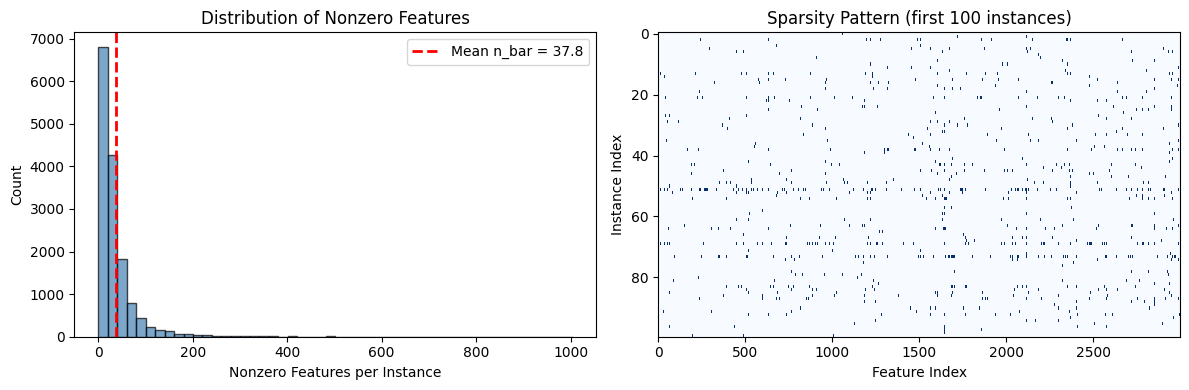

Saved: results/task_2_1_sparsity.png


In [3]:
import matplotlib.pyplot as plt
import os
os.makedirs('results', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of nonzero features per instance
axes[0].hist(nnz_per_row, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(n_bar, color='red', linestyle='--', linewidth=2,
                label=f'Mean n_bar = {n_bar:.1f}')
axes[0].set_xlabel('Nonzero Features per Instance')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Nonzero Features')
axes[0].legend()

# Sparsity pattern (first 100 instances)
sample = X_train[:100].toarray()
axes[1].imshow(sample != 0, cmap='Blues', aspect='auto', interpolation='none')
axes[1].set_xlabel('Feature Index')
axes[1].set_ylabel('Instance Index')
axes[1].set_title('Sparsity Pattern (first 100 instances)')

plt.tight_layout()
plt.savefig('results/task_2_1_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/task_2_1_sparsity.png")

### Explanation: Sparsity Visualization
The histogram confirms that most instances have a small number of nonzero features (tightly clustered around $\bar{n}$), and the sparsity pattern plot shows the data is overwhelmingly zero-valued — both confirming sparse TF-IDF text data is well-suited for the paper's method.

**Paper reference:** Section 3.3, Equation (10).